<a href="https://colab.research.google.com/github/Diego-LeivaC/market-leiva/blob/main/market-notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Data Loading**

In [55]:
import os
os.environ['KAGGLE_USERNAME'] = "xxxxxxx"
os.environ['KAGGLE_KEY'] = "xxxxxxx"
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows


Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
imdb-dataset-of-top-1000-movies-and-tv-shows.zip: Skipping, found more recently modified local copy (use --force to force download)


In [56]:
!unzip *.zip

Archive:  imdb-dataset-of-top-1000-movies-and-tv-shows.zip
replace imdb_top_1000.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: imdb_top_1000.csv       


In [57]:
import pandas as pd

data = pd.read_csv("imdb_top_1000.csv")
data.head(3)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"


# **Data Analysis and Preprocessing**

In [58]:
data.shape

(1000, 16)

There are 1000 rows (1000 films) and 16 columns.

In [59]:
data.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

The column 'Series_Title' refers to the film's name.

In [60]:
data['Series_Title'].isnull().sum()

np.int64(0)

All films are completed.

The columns: 'Star1', 'Star2', 'Star3', 'Star4' are the actor names.

In [61]:
data[['Star1','Star2','Star3','Star4']].isnull().sum()

,0
Star1,0
Star2,0
Star3,0
Star4,0


All actors are completed.

In [62]:
data = data.drop_duplicates()
data.shape

(1000, 16)

There are no duplicates.

In [63]:
for col in ["Star1","Star2","Star3","Star4"]:
    data[col] = data[col].str.strip().str.lower()

To uniformize the actor's names, those are without extra space and in lowercase.



# **The Market-Basket Model**

Considering that each film is to be considered a basket, and actors listed under the Star1, Star2, Star3 and Star4 fields as items. I transform each film in a list of actors.

In [64]:
transactions = data[['Star1','Star2','Star3','Star4']].values.tolist()

In [65]:
import random
print(random.sample(transactions, 2))

[['kangana ranaut', 'rajkummar rao', 'lisa haydon', 'jeffrey ho'], ['gael garcía bernal', 'rodrigo de la serna', 'mía maestro', 'mercedes morán']]



# **A-priori algorithm**

In [66]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

# Creates an object that can transform data (actor names) to a mathematic format.
transaction_encoder = TransactionEncoder()

# Convert the variable "transactions", transforming it into a boolean matrix False/True.
te_array = transaction_encoder.fit(transactions).transform(transactions)

# Convert the matrix into a table
data_encoded = pd.DataFrame(te_array, columns=transaction_encoder.columns_)

In [67]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
data_encoded.head(3)

,aamir bashir,aamir khan,aaron eckhart,aaron taylor-johnson,abdel ahmed ghili,abhay deol,abigail breslin,abraham attah,adam baldwin,adam driver,...,ziyi zhang,zoe saldana,zooey deschanel,zoë kravitz,álvaro guerrero,çetin tekindor,émile vallée,éric toledano,ömer faruk sorak,özge özberk
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


**Interpretation:**

"True" means that the actor appears in the film, "False" means that not. For instance, among the 2709 actors, Aaron Eckhart was the star 3 of the film The Dark Knight, this film was efectively in the row 2 on the original dataset.

The next code uses s = 0.01

In [68]:
frequent_combinations = apriori(data_encoded, min_support=0.01, use_colnames=True)
frequent_combinations.shape

(9, 2)

In [69]:
# Orders by frequency, most frequent actors of the dataset, to see also the maximun support
frequent_combinations.sort_values("support", ascending=False).head(9)

,support,itemsets
7,0.017,(robert de niro)
8,0.014,(tom hanks)
0,0.013,(al pacino)
1,0.012,(brad pitt)
3,0.012,(clint eastwood)
6,0.011,(matt damon)
2,0.011,(christian bale)
5,0.011,(leonardo dicaprio)
4,0.010,(james stewart)


**Interpretation:**

The maximum support threshold is 0.017.
Robert De Niro appears in 1.7% of films, meaning that De Niro appears in 17 of the 1000 films in the dataset. The same logic applies to the rest of actors.

Testing different support threshold

In [70]:
supports = [0.017, 0.005, 0.002, 0.0012]

results = []
for s in supports:
    result = apriori(data_encoded, min_support=s, use_colnames=True)
    results.append((s, len(result)))

pd.DataFrame(results, columns=["support","num_itemsets"])

,support,num_itemsets
0,0.0170,1
1,0.0050,83
2,0.0020,791
3,0.0012,791


**Interpretation:**

As expected only one itemset (Robert De Niro) has the support 0.017, as the support threshold decreases the number of itemsets increases, where 0.0020 and 0.0012 have the same number since 1.2 films is equivalent to 2 films because the algorihm works with whole numbers.
From now on 0.002 is considered the lowest support with 791 itemsets.

# **Multi-Actor Itemsets**

The next code block filters the results to show combinations of two or more actors, reducing the support threshold to 0.002 (which means it's enough that they've appeared together in 2 films)

In [71]:
frequent_combinations = apriori(data_encoded, min_support=0.002, use_colnames=True)

# Create a column with the length of each combination
frequent_combinations['length'] = frequent_combinations['itemsets'].apply(lambda x: len(x))

# Filter to show only combinations of 2 or more actors sorted by support
frequent_combinations[frequent_combinations['length'] >= 2].sort_values("support", ascending=False).head()

,support,itemsets,length
689,0.006,"(daniel radcliffe, rupert grint)",2
687,0.005,"(daniel radcliffe, emma watson)",2
774,0.005,"(daniel radcliffe, rupert grint, emma watson)",3
701,0.005,"(rupert grint, emma watson)",2
723,0.004,"(joe pesci, robert de niro)",2


**Interpretation:**

The maximum support is 0.006, corresponding to Daniel Radcliffe and Rupert Grind, it means that they appeared together in 6 films. It is present a length 3 with support 0.005 to the same previous actors and Emma Watson. This trio happened automatically because in Pass 2, the algorithm noticed that:


*   Daniel and Rupert are a frequent pair (6 movies).

*   Daniel and Emma are a frequent pair (5 movies).


*   Rupert and Emma are a frequent pair (5 movies).

Since all subsets were frequent, A-Priori generated the 3-actor candidate in its third pass and confirmed that they do, in fact, exceed the 0.002 threshold.

In [72]:
frequent_combinations[frequent_combinations['length'] >= 4].sort_values("support", ascending=False).head()

,support,itemsets,length
787,0.002,"(harrison ford, billy dee williams, mark hamil...",4
788,0.002,"(michael gambon, daniel radcliffe, rupert grin...",4
789,0.002,"(daryl hannah, michael madsen, david carradine...",4
790,0.002,"(elijah wood, orlando bloom, ian mckellen, vig...",4


In [73]:
frequent_combinations[frequent_combinations['length'] >= 5].shape

(0, 3)

As expected the maximum combinations are with length 4, there are no combinations with length equal o higher than 5. After identifying frequent itemsets of actors using Apriori, it is retrieved the corresponding films by filtering the original dataset and selecting only records containing the actors of the last itemset.

In [74]:
target_stars = ['viggo mortensen', 'elijah wood', 'ian mckellen', 'orlando bloom']
cols = ['Star1','Star2','Star3','Star4']
result = data[data[cols].apply(lambda r: set(target_stars).issubset(set(r)), axis=1)]
result[['Series_Title'] + cols]

,Series_Title,Star1,Star2,Star3,Star4
5,The Lord of the Rings: The Return of the King,elijah wood,viggo mortensen,ian mckellen,orlando bloom
13,The Lord of the Rings: The Two Towers,elijah wood,ian mckellen,viggo mortensen,orlando bloom


The itemset of the above mentioned actors are consireded in exactly 2 films of The Lord of the Rings, satisfying the support of 0.002.

# **Generating Association Rules**

In [75]:
from mlxtend.frequent_patterns import association_rules

# Generate association rules based on a minimum confidence threshold with 0.50
rules = association_rules(frequent_combinations, metric="confidence", min_threshold=0.50)

# Sort the rules by 'lift' (interest) and 'confidence' to see the strongest relationships first
rules_sorted = rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

# Display the top 4 highest rules
rules_sorted.head(4)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(nikolay grinko),(anatoliy solonitsyn),0.002,0.002,0.002,1.0,500.0,1.0,0.001996,inf,1.0,1.0,1.0,1.0
5,(anatoliy solonitsyn),(nikolay grinko),0.002,0.002,0.002,1.0,500.0,1.0,0.001996,inf,1.0,1.0,1.0,1.0
6,(milhem cortaz),(andré ramiro),0.002,0.002,0.002,1.0,500.0,1.0,0.001996,inf,1.0,1.0,1.0,1.0
7,(andré ramiro),(milhem cortaz),0.002,0.002,0.002,1.0,500.0,1.0,0.001996,inf,1.0,1.0,1.0,1.0


**Interpretation:**

The first three rules show a Confidence of 1.0 and a very high Lift of 500. Anatoliy Solonitsyn -> Nikolay Grinko: This rule has 100% confidence. This means that in every single film in this dataset where Anatoliy Solonitsyn (I) appears, Nikolay Grinko (j) is also present. These rules have a Lift of 500. A high lift (interest) indicates that these actors are not just popular individually, but that their presence is heavily "caused" by or correlated with the other.

In [76]:
rules_sorted.tail(4)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
119,(joe russo),(scarlett johansson),0.004,0.009,0.002,0.500000,55.555556,1.0,0.001964,1.982,0.985944,0.181818,0.495459,0.361111
95,(franka potente),(matt damon),0.004,0.011,0.002,0.500000,45.454545,1.0,0.001956,1.978,0.981928,0.153846,0.494439,0.340909
116,(joe pesci),(robert de niro),0.006,0.017,0.004,0.666667,39.215686,1.0,0.003898,2.949,0.980382,0.210526,0.660902,0.450980
2,(diane keaton),(al pacino),0.006,0.013,0.003,0.500000,38.461538,1.0,0.002922,1.974,0.979879,0.187500,0.493414,0.365385


**Interpretation:**

Joe Pesci -> Robert De Niro: This rule has a Confidence of 0.666667. This implies that if Joe Pesci is in the movie, there is a 66.66 chance that Robert De Niro is also in it. Joe Russo -> Scarlett Johansson: This rule has a Confidence of 0.50. This means that in half of the movies where Joe Russo appears, Scarlett Johansson is also a "Star" in the basket. Notice that the lift here is lower (around 39.2 to 55.5) compared to the 500 at the top list. This is because Robert De Niro and Scarlett Johansson are very frequent items on their own. Since they appear in many movies, the "surprise" of finding them with a specific partner is mathematically lower than with less frequent actors.

# **SON Algorithm**

In [77]:
import math

def SON(data_encoded, support, chunks=4):

    chunk_size = math.ceil(len(data_encoded)/chunks)
    candidates = set()

    # Pass 1: local frequent itemsets
    for i in range(0, len(data_encoded), chunk_size):

        chunk = data_encoded.iloc[i:i+chunk_size]

        reduced_support = support * (len(chunk)/len(data_encoded))

        freq = apriori(chunk, min_support=reduced_support, use_colnames=True)

        for itemset in freq["itemsets"]:
            candidates.add(frozenset(itemset))

    # Pass 2: count candidates globally
    candidate_list = list(candidates)

    counts = {c:0 for c in candidate_list}

    for _, row in data_encoded.iterrows():
        basket = set(data_encoded.columns[row])
        for candidate in candidate_list:
            if candidate.issubset(basket):
                counts[candidate]+=1

    # final frequent
    final = []
    for candidate,count in counts.items():
        if count/len(data_encoded) >= support:
            final.append((candidate,count/len(data_encoded)))

    return pd.DataFrame(final, columns=["itemsets","support"])

In [78]:
SON_results = SON(data_encoded, support=0.002, chunks=4)
SON_results.sort_values("support", ascending=False).head()

,itemsets,support
486,(robert de niro),0.017
538,(tom hanks),0.014
76,(al pacino),0.013
4,(brad pitt),0.012
148,(clint eastwood),0.012


In [79]:
SON_results.shape

(791, 2)

Similar to A-priori, at support 0.002 SON has 791 itemsets, but in this case there's is no memory crash when the threshold is 0.001, with the following result:

In [80]:
SON_results = SON(data_encoded, support=0.001, chunks=4)
SON_results.sort_values("support", ascending=False).tail()

,itemsets,support
4633,"(bertil guve, kristina adolphson)",0.001
4634,"(lorraine gary, richard dreyfuss)",0.001
4635,"(tsutomu tatsumi, ayano shiraishi)",0.001
4637,"(will poulter, domhnall gleeson)",0.001
4624,(peter ramsey),0.001


In [81]:
SON_results.shape

(13492, 2)

**Interpretation:**

A-priori fails at s=0.001 because it generates all possible candidate itemsets globally, causing a combinatorial explosion in memory usage. In contrast, SON remains efficient because it partitions the dataset and performs local mining first, drastically reducing the number of candidates itemsets that must be evaluated globally. This proves why SON is more scalable than Apriori for very low support values.

The number of frequent itemsets at that support equals the number of unique actor combinations that appear in at least one film. Since each film contains four actors, the theoretical maximum is 15 combinations per movie (2^4-1), leading to an upper bound of 15,000 itemsets(1000*15). The observed value of 13,492 is close to this bound, indicating that most actor combinations occur only once and that overlap between combinations across films is limited.

# **Toivonen’s Algorithm**

In [82]:
def Toivonen(data_encoded, support, sample_frac=0.6):

    sample = data_encoded.sample(frac=sample_frac, random_state=27)

    frac_support = support * 0.8

    freq_sample = apriori(sample, min_support=frac_support, use_colnames=True)

    candidates = [frozenset(i) for i in freq_sample["itemsets"]]

    counts = {c:0 for c in candidates}

    for _, row in data_encoded.iterrows():
        basket = set(data_encoded.columns[row])
        for candidate in candidates:
            if candidate.issubset(basket):
                counts[candidate]+=1

    final = []
    for candidate,count in counts.items():
        if count/len(data_encoded) >= support:
            final.append((candidate,count/len(data_encoded)))

    return pd.DataFrame(final, columns=["itemsets","support"])

In [83]:
Toivonen_results = Toivonen(data_encoded, support=0.002)
Toivonen_results.sort_values("support", ascending=False).head()

,itemsets,support
452,(robert de niro),0.017
526,(tom hanks),0.014
5,(al pacino),0.013
52,(brad pitt),0.012
102,(clint eastwood),0.012


In [84]:
Toivonen_results.shape

(698, 2)

**Interpretation:**

The shape is different than A-priori and SON, because candidate itemsets are generated from a random subset of the data, and different executions may produce slightly different results.

In [85]:
Toivonen_results = Toivonen(data_encoded, support=0.001)
Toivonen_results.sort_values("support", ascending=False).tail()

,itemsets,support
3162,"(david thewlis, zac mattoon o'brien)",0.001
3161,"(rupert friend, david thewlis)",0.001
3160,"(david thewlis, lesley sharp)",0.001
3159,"(katrin cartlidge, david thewlis)",0.001
3173,"(gene kelly, debbie reynolds)",0.001


In [86]:
Toivonen_results.shape

(8320, 2)

**Interpretation:**

At a support of 0.001, the algorithm successfully executes without memory issues because it does not attempt to enumerate all possible itemsets; instead, it first extracts candidate itemsets from a random subset of the dataset and only then validates those candidates against the full data.

However, the number of frequent itemsets obtained is considerably lower than the 13,492 itemsets found by SON. This difference occurs because Toivonen only evaluates itemsets that appear in the initial random sample. If a frequent itemset does not appear in the sample, it will never be considered as a candidate, leading to false negatives.

# **Experiments**

**Experiment 1 - Different supports**

In [87]:
import time

supports = [0.01,0.005,0.002]

results = []

for s in supports:

    # ---------- APRIORI ----------
    start = time.time()
    apriori(data_encoded, min_support=s, use_colnames=True)
    t_ap = time.time()-start

    # ---------- SON ----------
    start = time.time()
    SON(data_encoded, s)
    t_son = time.time()-start

    # ---------- TOIVONEN ----------
    start = time.time()
    Toivonen(data_encoded, s)
    t_toi = time.time()-start

    results.append((s,t_ap,t_son,t_toi))

# ---------- RESULT ----------
exp1 = pd.DataFrame(results, columns=["support","apriori","SON","Toivonen"])
exp1

,support,apriori,SON,Toivonen
0,0.010,0.009933,10.586081,0.065557
1,0.005,0.022770,10.240839,0.098917
2,0.002,0.929999,10.015763,19.741232


**Interpretation:**

A-priori performs very efficiently on this dataset across the thresholds. Although execution time increases when support decreases, the absolute difference is very small. In contrast, SON exhibits high execution times regardless of the support threshold. This indicates that, for a dataset of this size, the overhead introduced by partitioning and performing two passes outweighs its scalability advantages. On the other hand, Toivonen performs efficiently at higher support values, like A-priori, but becomes significantly slower at s 0.002, where candidate verification against the full dataset becomes computationally expensive. Overall, this first experiment suggests that for small to medium-sized datasets, A-priori outperform more scalable algorithms, since the additional overhead of partitioning or sampling does not provide benefits at this scale.

**Experiment 2 - Different sizes**

In [88]:
sizes = [200,400,600,800,1000]
support = 0.002

results = []

for s in sizes:

    subset = data_encoded.iloc[:s]

    # ---------- APRIORI ----------
    start = time.time()
    apriori(subset, min_support=support, use_colnames=True)
    t_ap = time.time() - start

    # ---------- SON ----------
    start = time.time()
    SON(subset, support=support, chunks=5)
    t_son = time.time() - start

    # ---------- TOIVONEN ----------
    start = time.time()
    Toivonen(subset, support=support)
    t_toi = time.time() - start

    results.append((s,t_ap,t_son,t_toi))

# ---------- RESULT ----------
exp2 = pd.DataFrame(results, columns=["size","Apriori","SON","Toivonen"])
exp2

,size,Apriori,SON,Toivonen
0,200,1.033948,0.251036,0.361774
1,400,6.995763,0.885240,1.872125
2,600,0.188825,2.129710,6.523665
3,800,0.457903,4.189932,11.406147
4,1000,0.925441,8.087493,19.662880


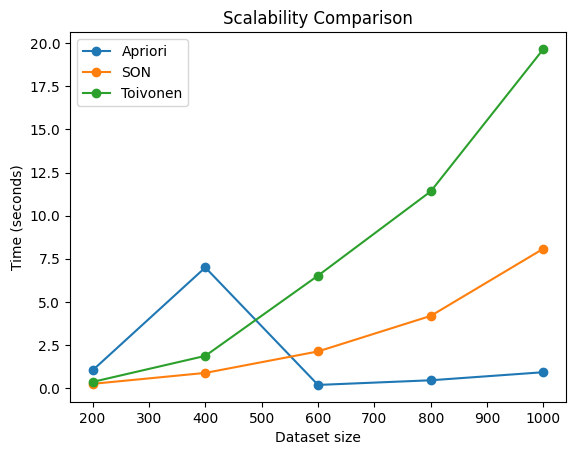

In [89]:
import matplotlib.pyplot as plt

exp2.set_index("size").plot(marker="o")
plt.title("Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Dataset size")
plt.show()

**Interpretation:**

SON and Toivonen exhibit a clear growth trend in runtime as dataset size increases, reflecting their dependence on scanning more baskets and validating candidates globally. Toivonen is the worst because it must both sample and verify candidates against the full dataset. Since the execution times are measured in seconds, SON and Toivonen remain significantly slower than A-priori across most tested sizes, with a substantial difference.

In the next code the sizes are the same but the fixed relative support is 0.006

In [90]:
sizes = [200,400,600,800,1000]
support = 0.006

results = []

for s in sizes:

    subset = data_encoded.iloc[:s]

    # ---------- APRIORI ----------
    start = time.time()
    apriori(subset, min_support=support, use_colnames=True)
    t_ap = time.time() - start

    # ---------- SON ----------
    start = time.time()
    SON(subset, support=support, chunks=5)
    t_son = time.time() - start

    # ---------- TOIVONEN ----------
    start = time.time()
    Toivonen(subset, support=support)
    t_toi = time.time() - start

    results.append((s,t_ap,t_son,t_toi))

# ---------- RESULT ----------
exp2 = pd.DataFrame(results, columns=["size","Apriori","SON","Toivonen"])
exp2

,size,Apriori,SON,Toivonen
0,200,0.017173,0.255115,0.375993
1,400,0.011149,0.871411,0.040910
2,600,0.011832,3.233206,0.117836
3,800,0.011967,4.231272,0.070219
4,1000,0.016613,7.459930,0.163577


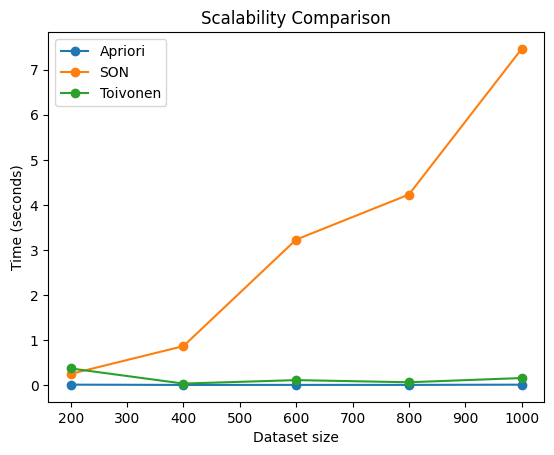

In [91]:
import matplotlib.pyplot as plt

exp2.set_index("size").plot(marker="o")
plt.title("Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Dataset size")
plt.show()

**Interpretation:**

A-priori remains the fastest algorithm across all dataset sizes, with execution time staying almost constant even as the number of transactions increases. In contrast, SON exhibits a clear growth in runtime as the dataset size increases, reflecting the overhead introduced by partitioning the dataset and performing multiple counting phases. Toivonen is much faster than SON but still slower than A-priori. It is also important to note that SON and Toivonen internally operate with even lower effective support thresholds, because SON evaluates candidates within partitions and Toivonen generates candidates from a sampled subset before validating them on the full dataset. This means they may temporarily consider more potential itemsets than A-priori, which helps them discover patterns at lower supports but also introduces additional computational overhead.

# **Scalability**

**First scalability**

In [92]:
sizes = [1000, 2500]

datasets = {}

for s in sizes:
    multiplier = s // len(data_encoded) + 1
    datasets[s] = pd.concat([data_encoded]*multiplier).iloc[:s]

support = 0.002
results = []

for size, df in datasets.items():

    # ---------- APRIORI ----------
    start = time.time()
    apriori(df, min_support=support, use_colnames=True)
    t_ap = time.time() - start

    # ---------- SON ----------
    start = time.time()
    SON(df, support=support, chunks=5)
    t_son = time.time() - start

    # ---------- TOIVONEN ----------
    start = time.time()
    Toivonen(df, support=support)
    t_toi = time.time() - start

    results.append((size, t_ap, t_son, t_toi))

# ---------- RESULT ----------
scale_df = pd.DataFrame(results, columns=["size","apriori","SON","Toivonen"])
scale_df

,size,apriori,SON,Toivonen
0,1000,1.338277,6.871237,20.239385
1,2500,5.012601,64.200827,3.963628


**Interpretation:**

Increasing the dataset size from 1,000 to 2,500 transactions has different effects across methods. A-priori does not demonstrate a clear increase. SON exhibits a huge increase, indicating that the overhead introduced by partitioning and performing multiple passes becomes increasingly expensive as data size increases. Toivonen's performance improves when the dataset size increases. This suggests that, under replicated data conditions, the sampling phase may generate a more stable or reduced candidate set, lowering the cost of the global verification step.

**Second scalability**

In [93]:
sizes = [20000,40000]

datasets = {}

for s in sizes:
    multiplier = s // len(data_encoded) + 1
    datasets[s] = pd.concat([data_encoded]*multiplier).iloc[:s]

support = 0.01
results = []

for size, df in datasets.items():

    # ---------- APRIORI ----------
    start = time.time()
    apriori(df, min_support=support, use_colnames=True)
    t_ap = time.time() - start

    # ---------- SON ----------
    start = time.time()
    SON(df, support=support, chunks=5)
    t_son = time.time() - start

    # ---------- TOIVONEN ----------
    start = time.time()
    Toivonen(df, support=support)
    t_toi = time.time() - start

    results.append((size, t_ap, t_son, t_toi))

# ---------- RESULT ----------
scale_df = pd.DataFrame(results, columns=["size","apriori","SON","Toivonen"])
scale_df

,size,apriori,SON,Toivonen
0,20000,0.083972,27.834466,1.211674
1,40000,0.122256,66.504059,2.392819


**Interpretation:**

When increasing the dataset size from 20,000 to 40,000 transactions with a higher support threshold (0.01), all algorithms exhibit growth in execution time, confirming scalability effects. A-priori scales very efficiently under this higher support value, showing only a small increase as the dataset doubles. This indicates that when the support threshold is relatively high, the number of frequent item sets remains limited, preventing candidate explosion and allowing A-priori to remain computationally efficient even at large sizes.
In contrast, SON shows a huge growth trend as dataset size increases, suggesting that its partitioning and multiple-pass structure introduces considerable overhead at larger scales. Toivonen also increases with dataset size, but its growth is more moderate compared to SON. This result demonstrates that with higher support thresholds, classical A-priori can outperform more advanced scalable algorithms.


**Third scalability**

In [94]:
sizes = [10000,20000]

datasets = {}

for s in sizes:
    multiplier = s // len(data_encoded) + 1
    datasets[s] = pd.concat([data_encoded]*multiplier).iloc[:s]

support = 0.002
results = []

for size, df in datasets.items():

    # ---------- TOIVONEN ----------
    start = time.time()
    Toivonen(df, support=support)
    t_toi = time.time() - start

    results.append((size, t_toi))

# ---------- RESULT ----------
scale_df = pd.DataFrame(results, columns=["size","Toivonen"])
scale_df

,size,Toivonen
0,10000,8.158483
1,20000,29.165491


**Interpretation:**

In the last measure, only Toivonen was able to complete execution when the dataset sizes are 10,000 and 20,000 with s 0.002. Although execution time increased as the dataset doubled, the algorithm remained stable and did not crash. This confirms that the sampling-based strategy of Toivonen effectively controls candidate explosion, making it more resilient in high-volume, low-support scenarios where A-priori and SON fail due to excessive memory consumption.